In [1]:
from attention_motifs.dataset.dataset import (
	APGenerationConfig,
	PromptDatasetConfig,
	CollectedAttentionPatternDataloader,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
d = CollectedAttentionPatternDataloader.generate(
	config=APGenerationConfig(
		prompts_config=PromptDatasetConfig.from_source_path("../data/pile_5_val.jsonl"),
		model_names=[
			"pythia-14m",
			"gpt2-small",
			"meta-llama/Llama-3.2-1B",
		],
	),
	max_batch_size=8,
)

# Processing model: pythia-14m
--------------------------------------------------
| (0.41s) Loading model pythia-14m                                             

The `GPTNeoXSdpaAttention` class is deprecated in favor of simply modifying the `config._attn_implementation`attribute of the `GPTNeoXAttention` class! It will be removed in v4.48


| (1.76s) Loading model pythia-14m                                             Loaded pretrained model pythia-14m into HookedTransformer
# (1.83s) Loading model pythia-14m                                             
#	loaded pythia-14m with 1179648 (1.2M) parameters
#	model devices: {device(type='cuda', index=0)}
# (0.04s) tokenizing and binning prompts                                       
#	shapes of each bin contents (n_seqs, n_ctx): [ (8, 192), (3, 128), (1, 256), (2, 64) ]
# getting attention patterns:


n_ctx = 64: 100%|██████████| 14.0/14.0 [00:00<00:00, 23.0Seq/s] 

# Processing model: gpt2-small
--------------------------------------------------
| (0.00s) Loading model gpt2-small                                             

...

| (3.55s) Loading model meta-llama/Llama-3.2-1B                                

/ (14.08s) Loading model meta-llama/Llama-3.2-1B                               Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
# (14.12s) Loading model meta-llama/Llama-3.2-1B                               
#	loaded meta-llama/Llama-3.2-1B with 1073741824 (1.1B) parameters
#	model devices: {device(type='cuda', index=0)}
# (0.06s) tokenizing and binning prompts                                       
#	shapes of each bin contents (n_seqs, n_ctx): [ (7, 192), (4, 128), (1, 256), (2, 64) ]
# getting attention patterns:


n_ctx = 64: 100%|██████████| 14.0/14.0 [00:34<00:00, 2.49s/Seq] 

/ (0.10s) assembling datasets                                                  

# (0.37s) assembling datasets                                                  
# done generating datasets! summary:
--------------------------------------------------
{
  "n_total_samples": 9520,
  "n_prompts": 14,
  "n_datasets": 4,
  "config": {
    "prompts_config": {
      "name": "pile_5_val",
      "source_path": "../data/pile_5_val.jsonl",
      "char_len_min": 64,
      "char_len_max": 1024
    },
    "model_names": [
      "pythia-14m",
      "gpt2-small",
      "meta-llama/Llama-3.2-1B"
    ],
    "token_len_min": 64,
    "prompt_token_len_tolerance": 64,
    "raw_scores": false
  },
  "dataset_shapes_summary": [
    "(5216, 192, 192)",
    "(2408, 128, 128)",
    "(536, 256, 256)",
    "(1360, 64, 64)"
  ]
}
--------------------------------------------------


In [4]:
d.save("../data/activations/pile_5_val", verbose=True)

# (0.07s) Saving metadata                                                      
# (0.05s) Saving prompts                                                       


Saving datasets: 100%|██████████| 4/4 [00:14<00:00,  3.74s/dataset]


torch.Size([2, 192, 192])
[AttentionPatternMetadata(model_name='pythia-14m', idx_layer=0, idx_head=0, n_ctx=192, prompt_hash=214244590), AttentionPatternMetadata(model_name='pythia-14m', idx_layer=0, idx_head=0, n_ctx=192, prompt_hash=1511282546)]


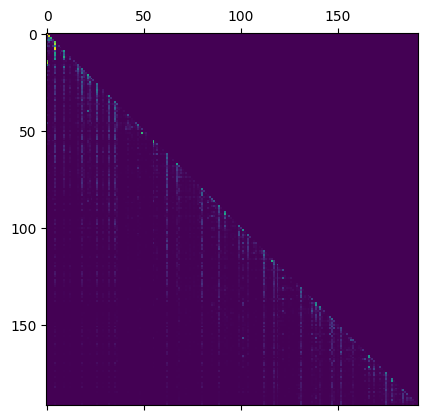

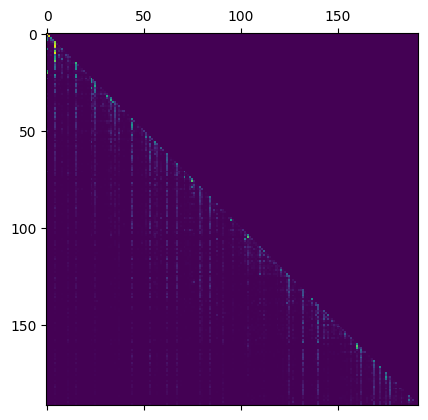

In [5]:
import matplotlib.pyplot as plt

for x in d.batches(2):
	print(x[0].shape)
	print(x[1])
	plt.matshow(x[0][0].cpu().numpy())
	plt.show()
	plt.matshow(x[0][1].cpu().numpy())
	plt.show()
	break